# Apresentação do Gas Refractometry Optimize

Esse notebook tem como propósito apresentar e explicar o projeto que venho desevolvendo, "Otimização Espectral para Mitigação de Mau-Condicionamento em Refratometria Gasosa", cuja as principais classes, funções e dados estão reunidas nesse repositório, abreviado para $\texttt{Gasopt}$. A proposta principal desse projeto é investigar o comportamento do índice de refração dos gases ao longo do espectro eletromagnético, do UV ao IR, afim de encontrar onde a solução do problema inverso da Regra Refrativa de Misturas (RRM) é menos mau condicionado. 

O foco do presente arquivo é explicar a implementação e uso da parte computacional do projeto. Dessa forma a discussão teórica e física do problema será deixada para as apresentações e relatório. Em caso de dúvidas e sugeestões entre em contato no meu email USP.

In [1]:
# comando pra clonar o repositorio no colab
# (apague o # para usar)
#!git clone https://github.com/MathWeb3r/gas_refractometry_optimize

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

try:
    import gasopt

except:
    import sys
    # forma de import o modulo no google colab
    sys.path.append('/content')
    from gas_refractometry_optimize import gasopt

# Dispersão e Refratividade

Para calcular a dispersão da luz nos gases, foi utilizada a equação de Sellmeier. Essa equação permite calcular a refratividade $(n-1)$ para um determinado comprimento de onda $\lambda$. Os coeficientes $A$, $B_j$ e $C_j$ são determinados via ajuste de curva para dados experimentais. 

$$
(n-1)_{\lambda} \approx  A + \sum_{j} \frac{B_{j}}{C_{j}-\lambda^{-2}}
$$

Há um arquivo [coeficientes_sellmeier.csv](../data/coeficientes_sellmeir.csv) que contém os coeficientes, com os artigos, e outras informações importantes (que serão, ou não, explicadas em breve). O repositório usa o arquivo [gas_database.json](../data/gas_database.json) gerado a partir do csv com os dados.

A implementação dessa é equação é feita pelo objeto ``Sellmeier``. Essa classe toma como parametros os coeficientes, na forma ``(A: float, B: np.ndarray , C: np.ndarray)``.

Para calcular a refratividade em um comprimento de onda $x$ específico, use o método ``calculate_sellmeier(x: float)``. A unidade de $x$ deve estar de acordo os coeficientes, mas em geral para nossos dados será usado $\mu\text{m}$.

In [3]:
def dispersao():
    # coeficientes para co2, para (n-1)*1e8
    escala = 1e-8
    sellmeier = gasopt.Sellmeier(A=7137.238, B=[6946980.0, 341712.4], C=[248.556, 57.7534])

    # Calculando a refratividade para 0.540 micrômetros
    refrac = sellmeier.calculate_sellmeier(x=0.540)
    print(f"Refratividade para 0.540 micrômetros: {refrac*escala}")

    # Calculando a refratividade no intervalo 0.600 a 0.800 micrômetros
    refrac_range = sellmeier.dispersion(start=0.600, end=0.800)
    lambdas = np.linspace(0.600, 0.800)

    # plotando a dispersão
    fig, ax = plt.subplots()
    ax.plot(lambdas, refrac_range*escala, label='Refratividade')
    ax.set_xlabel('Comprimento de onda (micrômetros)')
    ax.set_ylabel('Refratividade')
    ax.set_title('Dispersão do CO2')
    ax.legend()


dispersao()

Refratividade para 0.540 micrômetros: 0.00041767869416970484


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

Ao invés de adicionar os coeficientes sempre, foi implementada a classe ``Gas``. Ela extende a ``Sellmeier``, além de poder acessar os dados 
dos coefientes.

Refratividade para 0.540 micrômetros: [4.17678694e-04 7.80000000e-08]


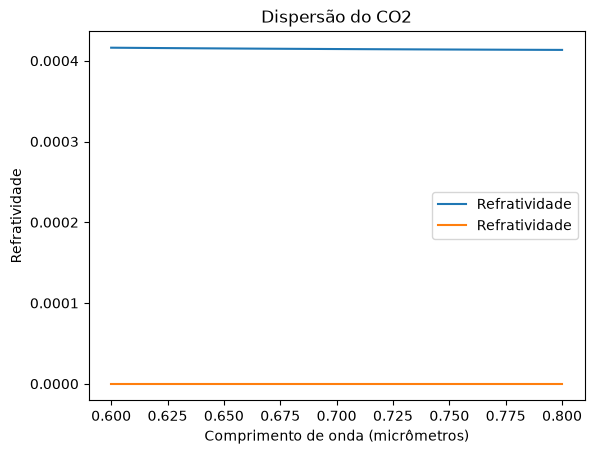

In [4]:
def dispersao_gas():
    # criando um objeto Gas para CO2, usando os dados do gas_database.json
    gas = gasopt.Gas(id='co2_1')

    # Calculando a refratividade para 0.540 micrômetros, da mesma forma
    # note que quando o gas é importado dos dados ele já
    # toma conta da escala, então não é necessário multiplicar por 1e-8
    refrac = gas.calculate_sellmeier(x=0.540)
    print(f"Refratividade para 0.540 micrômetros: {refrac}")

    # Calculando a refratividade no intervalo 0.600 a 0.800 micrômetros
    refrac_range = gas.dispersion(start=0.600, end=0.800)

    # o metodo dispersion retorna um array de refratividades,
    # feito a partir do np.linspace, então para plotar a dispersão 
    # é necessário criar um array de lambdas de mesmo tamanho
    lambdas = np.linspace(0.600, 0.800, len(refrac_range))

    # um jeito equivalente de obter a array de dispersao seria 
    # refrac_range = [gas.calculate_sellmeier(x) for x in lambdas]

    # plotando a dispersão
    fig, ax = plt.subplots()
    ax.plot(lambdas, refrac_range, label='Refratividade')
    ax.set_xlabel('Comprimento de onda (micrômetros)')
    ax.set_ylabel('Refratividade')
    ax.set_title('Dispersão do CO2')
    ax.legend()

dispersao_gas()

É possível verificar os gases implementados acessando os arquvios na pasta 'data'. 

A classe $\texttt{gasopt.Gas()}$ tem os seguintes atributos:

 - ``name``: Nome do gás
 - ``t_ref``: Tempertatura de refêrencia, do artigo
 - ``p_ref``: Pressão de refrência, do artigo
 - ``multiplier``: Multiplier representa o $10^n$ quando a equação retorna $(n-1) \times 10^n$
 - ``range``: Intervalo de validade dos coeficientes em $\mu\text{m}$
 - ``reference``: Artigo de refêrencia


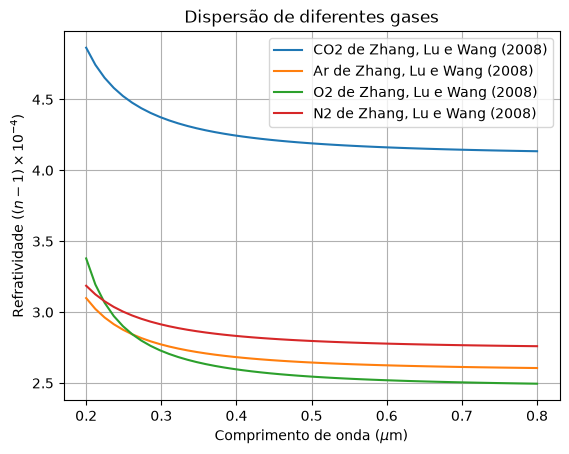

In [13]:
def exemplo_gases():
    # alguns exemplos de gases disponíveis no gas_database.json
    gases_id = ['co2_1', 'ar_1', 'o2', 'n2_1']

    # Config do plot
    fig, ax = plt.subplots()
    ax.set_xlabel('Comprimento de onda ($\\mu \\text{m}$)')
    ax.set_ylabel('Refratividade ($(n-1)\\times 10^{-4}$)')
    ax.set_title(f'Dispersão de diferentes gases')

    for gas_id in gases_id:
        # criando um objeto Gas para CO2, usando os dados do gas_database.json
        gas = gasopt.Gas(id=gas_id)

        # Calculando a refratividade no intervalo 200 a 800 micrômetros
        inicio = 0.200
        fim = 0.800
        refracs = gas.dispersion(start=inicio, end=fim)
        
        # arrumar isso com slicing
        # gambiarra provisioria
        refracs = np.array([i[0] for i in refracs])
        
        lambdas = np.linspace(inicio, fim, len(refracs))

        # plotando a dispersão, ajustando a escala do eixo y para melhor visualização
        # usando os atributos name e reference do gas para a legenda
        ax.plot(lambdas, refracs*1e4, label=f'{gas.name} de {gas.reference}')
        
    ax.grid()
    ax.legend()
        

exemplo_gases()

# Matriz A e Número de Condição

A Regra Refrativa de Misturas (RRM) permite determinar o vetor de frações molares $\Phi$ dos gases com a solução do sistema.

$$
A \Phi = b
$$

A explicação desse está nos slides de apresentação do proejto. 

A matrix $A$ pode ser pensada como o operador de dispersão do nosso sistema de gases. Cada elemento $a_{i,j}$ é a refratividade $(n-1)$ do gas $i$ para o comprimento de onda $j$. Ou seja, cada coluna representa um gás e cada linha um comprimento de onda.

No ``gasopt`` essa matrix é implementada com o objeto ``GasMix``, que toma como parametros ``(gases: np.array, wvlens: np.array, temp: float)``, ``gases`` é array em que cada elemento é do tipo ``Gas``, ``wvlens`` uma array com os comprimentos de onda em $\mu\text{m}$ e ``temp`` é um float da temperatura do sistema em K. Para criar uma matriz, use o método ``get_matrix()``.

Outra informação importante da matriz é o seu número de condição $\kappa(A)$, que pode ser encontrado pelo método ``cond_number()``. 

In [ ]:
def exemplo_matrixA():
    # escolho os gases que eu quero
    gases_id = ['co2_1', 'n2_1', 'o2', 'ar_1']

    # crio a array com os objetos Gas
    gases = [gasopt.Gas(id=id) for id in gases_id]

    # escolho os comprimentos de onda, em micron
    lambdas = [0.450, 0.540, 0.645, 0.860]

    # crio o objeto GasMatrix
    disp_operator = gasopt.GasMix(
        gases=gases,
        wvlens=lambdas,
        temp = 273.15 #k
    )

    # crio a matriz
    mtx = disp_operator.get_matrix()

    # numero de condição 
    kappa = mtx.cond_number()

    # fazendo um print bonito pra visualizar
    print('Matrix A')
    print(f'\nLambda | ', end='')
    [print('', gas.name, (' ')*(10-len(gas.name)-1), end='') for gas in gases]
    print()
    [print(f'{w*1e3:.1f}{' '*(4-len(str(round(w*1e3))))} | {i}') for i, w in zip(mtx, lambdas)]
    print(f'\nNúmero de condição da matriz: {kappa}')

    # outra foram de se calcular o numero de condição é 
    kappa = np.linalg.cond(mtx)


exemplo_matrixA()

Matrix A

Lambda |  CO2        N2         O2         Ar        
450.0  | [0.00045207 0.00030171 0.0002754  0.00028551]
540.0  | [0.00044826 0.00029921 0.00027188 0.00028285]
645.0  | [0.00044574 0.00029754 0.00026961 0.00028109]
860.0  | [0.00044322 0.00029586 0.00026738 0.00027932]

Número de condição da matriz: 19216224.53360929


# Simulação pelo método de Inversão

A solução pelo método de inversão direta é feita pelos seguintes passos: Primeiro escolho um conjunto de gases, um conjunto de comprimento de ondas e uma vetor $\Phi_{real}$. A matriz $A$ é gerada pelos gases e comprimentos de onda, então calculo $b$ por $A\Phi = b$. Depois adiciono um ruído ao vetor $b$ para simular o resultado experimental, $b + \delta b$. Por último soluciono o problema inverso encontrando o vetor molar simulado, por $A^{-1}(b+\delta b) = \Phi_{sim}$.

No ``gasopt``, a simulação é implementada pela classe ``SimulationRRM``, que toma como parâmetros ``gases_id`` a lista dos id's dos gases do sistema, ``lambdas`` uma lista do conjunto dos comprimentos de onda, ``

In [ ]:
def exemplo_simulacao(erro):
    # escolhendo gases
    gases_id = ['co2_1', 'o2', 'n2_1', 'ar_1']
    
    # extrapolando os limites dos gases 
    # selecionados, pelo exemplo
    lambdas = [0.2, 0.4, 0.6, 0.8]

    # definindo a fração molar real
    # a ordem das frações é a mesma ordem dos gases
    phi = [0.05, 0.3, 0.7, 0.15]

    # criando simulação
    sim = gasopt.SimulationRRM(
        gases_id=['co2_1', 'o2', 'n2_1', 'ar_1'],
        lambdas=np.linspace(0.2, 0.86, 4),
        phi=[0.25, 0.25, 0.25, 0.25],
        erro=erro, # porcetagem
        temp=273.15 # K
    )

    # executando 10 simulações
    phi_sim = sim.run_simulation(n_iter=10, method='lstsq')

    return phi_sim

In [ ]:
print("Frações molares simuladas, com erro 1%")
print(exemplo_simulacao(erro=0.01))

Frações molares simuladas, com erro 1%
[[ 5.82192697e+02 -3.68012651e+02 -1.89450191e+03  1.43629731e+03]
 [ 4.35349241e+02 -2.71555532e+02 -1.40192815e+03  1.05523426e+03]
 [ 2.09893537e+02 -1.36314795e+02 -6.99588156e+02  5.39582918e+02]
 [-5.48644694e+02  3.48915727e+02  1.79433391e+03 -1.36284135e+03]
 [-3.32369706e+02  2.10649722e+02  1.08291834e+03 -8.20138205e+02]
 [-2.50947223e+02  1.58883671e+02  8.17109637e+02 -6.18243514e+02]
 [ 3.79680387e+02 -2.40492596e+02 -1.23850902e+03  9.40723110e+02]
 [ 3.91152361e+02 -2.44258476e+02 -1.26038136e+03  9.49305209e+02]
 [ 1.62451536e+02 -9.43800104e+01 -4.93494174e+02  3.56445942e+02]
 [-1.26698896e+00  4.55399902e+00  1.99062219e+01 -2.22670546e+01]]


In [ ]:
print("\nFrações molares simuladas, com erro 0.0001%")
print(exemplo_simulacao(erro=0.000001))


Frações molares simuladas, com erro 0.0001%
[[0.23747295 0.25772978 0.28997069 0.22014049]
 [0.27240389 0.23701979 0.18216833 0.29872419]
 [0.26318272 0.24091762 0.20392253 0.2865806 ]
 [0.26566691 0.23983847 0.19787396 0.29007747]
 [0.22363763 0.26609771 0.3333352  0.18815198]
 [0.22653174 0.26507633 0.32742704 0.19079664]
 [0.23376143 0.26035667 0.30328787 0.20941055]
 [0.2751244  0.23381675 0.16688431 0.31366099]
 [0.24947141 0.25005056 0.25050521 0.25025471]
 [0.25313022 0.24825824 0.24085976 0.25638196]]


Com os exemplos acima, se percebe que existem soluções fisicamente impossíveis com frações molares negativas e vetores com norma difrerente de 1. Pensando em solucionar isso, foi implementado o método "constrain" (que significa restringir) à classe ``SimulationRRM``. Para utilizado basta escolhe-lo pelo argumento "method" quando executar a simulação,  ``.run_simulation(method='constrain)'``. 

Esse método tenta calcular $ \text{min} \left( ||A\Phi - b_{ruído}||^2 \right)$, restrito à $||\Phi|| = 1$ (Soma das frações igual à 1) e $0 \le \Phi_j \le 1,  \Phi_j \in \Phi$ (Frações positivas e menores que 1)

In [ ]:
def exemplo_simulacao_restrita(gases_id, phi, lambdas, erro):
    # criando simulação
    sim = gasopt.SimulationRRM(
        gases_id=gases_id,
        lambdas=lambdas,
        phi=phi,
        erro=erro, # porcetagem
        temp=273.15 # K
    )

    print('kappa(A): ', sim.mtx.cond_number())

    # executando 10 simulações
    # escolhendo o método com as restrições
    phi_sim = sim.run_simulation(n_iter=10, method='constrain')

    print('Soluções para 10 iterações: ')
    for phi in phi_sim:
        print('Soma: ', round(sum(phi), 3), '| Phi: ', phi)

No entando, para $\kappa(A)$ muito grandes essa função não converge corretamente. Isso não é uma questão do algoritimo, mas sim do mau-condicionamento do problema.

In [ ]:
exemplo_simulacao_restrita(
    gases_id=['co2_1', 'o2', 'ar_1', 'n2_1'],
    phi = [0.1, 0.3, 0.2, 0.4],
    lambdas = [0.4, 0.55, 0.65, 0.8],
    erro = 0.001 # 0.1%
)

kappa(A):  16525957.349202098
Soluções para 10 iterações: 
Soma:  1.0 | Phi:  [0.49999972 0.         0.50000028 0.        ]
Soma:  1.0 | Phi:  [1.66533454e-16 5.00000029e-01 0.00000000e+00 4.99999971e-01]
Soma:  1.0 | Phi:  [1.11022302e-16 5.00000029e-01 0.00000000e+00 4.99999971e-01]
Soma:  1.0 | Phi:  [0.00000000e+00 5.00000029e-01 5.55111512e-17 4.99999971e-01]
Soma:  1.0 | Phi:  [1.11022302e-16 5.00000029e-01 1.11022302e-16 4.99999971e-01]
Soma:  1.0 | Phi:  [0.         0.50000003 0.         0.49999997]
Soma:  1.0 | Phi:  [4.99999716e-01 1.66533454e-16 5.00000284e-01 0.00000000e+00]
Soma:  1.0 | Phi:  [4.99999717e-01 1.38777878e-16 5.00000283e-01 0.00000000e+00]
Soma:  1.0 | Phi:  [4.99999717e-01 2.77555756e-17 5.00000283e-01 0.00000000e+00]
Soma:  1.0 | Phi:  [0.00000000e+00 5.00000029e-01 5.55111512e-17 4.99999971e-01]


In [ ]:
# diminuindo o erro
# matriz com numero de condição de bem pequeno
exemplo_simulacao_restrita(
    gases_id=['co2_1', 'ar_1'],
    phi = [0.7, 0.3],
    lambdas = [0.4, 0.8],
    erro = 0.001 # 0.001
)

kappa(A):  1573.474017252217
Soluções para 10 iterações: 
Soma:  1.0 | Phi:  [1. 0.]
Soma:  1.0 | Phi:  [0.13340587 0.86659413]
Soma:  1.0 | Phi:  [0.73678277 0.26321723]
Soma:  1.0 | Phi:  [0.24341633 0.75658367]
Soma:  1.0 | Phi:  [0.73508855 0.26491145]
Soma:  1.0 | Phi:  [0.70833917 0.29166083]
Soma:  1.0 | Phi:  [0.36047914 0.63952086]
Soma:  1.0 | Phi:  [1. 0.]
Soma:  1.0 | Phi:  [0.98922864 0.01077136]
Soma:  1.0 | Phi:  [0.53370665 0.46629335]
